# 14. Procesamiento con Spark y Deep Learning

## 14.1 Objetivo del notebook

En este notebook se amplía el análisis predictivo desarrollado anteriormente mediante la incorporación de dos herramientas adicionales: **Apache Spark**, para el procesamiento de los datos, y una **red neuronal multicapa (MLP)** implementada con TensorFlow/Keras como nuevo modelo de clasificación.

El objetivo es evaluar si una arquitectura de Deep Learning permite mejorar la clasificación de los códigos de calidad asociados a las componentes de irradiancia **GHI, DNI y DHI**, manteniendo el mismo marco experimental utilizado con los modelos clásicos.

Para garantizar que los resultados sean comparables con los obtenidos previamente, se conservarán:

- los mismos tres targets: `codigo_ghi`, `codigo_dni` y `codigo_dhi`;
- el mismo conjunto de features definido tras su análisis en el notebook anterior;
- la separación temporal interanual, utilizando **2024 para entrenamiento y 2023 como conjunto de test externo**;
- el mismo tratamiento de valores ausentes y escalado definido mediante las funciones comunes del proyecto;
- las mismas métricas de evaluación, tomando **Macro F1** como métrica principal y complementándola con Balanced Accuracy y Weighted F1.

Spark se utilizará para realizar la carga y preparación inicial del dataset, mientras que TensorFlow/Keras se empleará para construir y entrenar los modelos MLP.

De este modo, el notebook permitirá incorporar técnicas de procesamiento distribuido y Deep Learning sin modificar las condiciones experimentales utilizadas previamente, posibilitando una comparación directa entre la MLP y los modelos clásicos.

In [ ]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import tensorflow as tf

In [ ]:
from src.preprocessing.model_preprocessing import prepare_model_features

from src.models.mlp import (
    get_class_weights,
    build_baseline_mlp,
    train_mlp,
)

from src.evaluation.evaluation import (
    evaluate_model_predictions,
    plot_confusion_matrices,
    plot_correct_predictions_by_class,
)

In [99]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_solar_2023_2024_v3.parquet"

TARGETS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi",
]

TRAIN_YEAR = 2024
TEST_YEAR = 2023

In [101]:
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-21.0.12"
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"


## 14.2 Carga y preparación del dataset con Spark

El dataset procesado se carga mediante **Apache Spark**, manteniendo la separación temporal utilizada durante el proyecto: **2024 como periodo de desarrollo del modelo y 2023 como test externo**. Spark se emplea para realizar las operaciones iniciales de lectura, filtrado, transformación y particionado antes de trasladar los datos al entorno de modelado con TensorFlow.

In [102]:
spark = (
    SparkSession.builder
    .appName("solar_irradiance_tfm")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")

Spark version: 4.2.0


In [103]:
spark_df = spark.read.parquet(str(DATA_PATH.resolve()))

print(f"Rows: {spark_df.count():,}")
print(f"Columns: {len(spark_df.columns)}")

spark_df.printSchema()

Rows: 1,052,640
Columns: 27
root
 |-- ano: long (nullable = true)
 |-- mes_sin: double (nullable = true)
 |-- mes_cos: double (nullable = true)
 |-- dia: long (nullable = true)
 |-- hora_sin: double (nullable = true)
 |-- hora_cos: double (nullable = true)
 |-- minuto: long (nullable = true)
 |-- fecha: timestamp_ntz (nullable = true)
 |-- ghi: double (nullable = true)
 |-- dni: double (nullable = true)
 |-- dhi: double (nullable = true)
 |-- ghi_estimado: double (nullable = true)
 |-- irr_null: boolean (nullable = true)
 |-- error_balance: double (nullable = true)
 |-- error_balance_abs: double (nullable = true)
 |-- error_balance_rel: double (nullable = true)
 |-- elevacion_solar: double (nullable = true)
 |-- periodo_solar: string (nullable = true)
 |-- temperatura: double (nullable = true)
 |-- velocidad_viento: double (nullable = true)
 |-- humedad_relativa: double (nullable = true)
 |-- direccion_viento_sin: double (nullable = true)
 |-- direccion_viento_cos: double (nullable = t

In [104]:
spark_df.show(
    5,
    truncate=False
)

+----+-------+-------+---+--------+--------+------+-------------------+---+---+---+------------+--------+-------------+-----------------+-----------------+------------------+-------------+-----------+----------------+----------------+--------------------+--------------------+-------------+----------+----------+----------+
|ano |mes_sin|mes_cos|dia|hora_sin|hora_cos|minuto|fecha              |ghi|dni|dhi|ghi_estimado|irr_null|error_balance|error_balance_abs|error_balance_rel|elevacion_solar   |periodo_solar|temperatura|velocidad_viento|humedad_relativa|direccion_viento_sin|direccion_viento_cos|var_meteo_imp|codigo_ghi|codigo_dni|codigo_dhi|
+----+-------+-------+---+--------+--------+------+-------------------+---+---+---+------------+--------+-------------+-----------------+-----------------+------------------+-------------+-----------+----------------+----------------+--------------------+--------------------+-------------+----------+----------+----------+
|2023|0.0    |1.0    |1  |0.

El dataset contiene **1.052.640 observaciones y 27 variables**, correspondientes a mediciones minuto a minuto de 2023 y 2024. El esquema detectado por Spark conserva correctamente los tipos numéricos, temporales, booleanos y categóricos definidos durante las etapas anteriores del procesamiento.

In [105]:
required_columns = [
    "ano",
    "fecha",
    *TARGETS,
]

missing_columns = [
    col for col in required_columns
    if col not in spark_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Required columns OK.")

Required columns OK.


In [106]:
spark_train = (
    spark_df
    .filter(F.col("ano") == TRAIN_YEAR)
    .cache()
)

spark_test = (
    spark_df
    .filter(F.col("ano") == TEST_YEAR)
    .cache()
)

n_train = spark_train.count()
n_test = spark_test.count()

print(f"Train ({TRAIN_YEAR}): {n_train:,} rows")
print(f"Test  ({TEST_YEAR}): {n_test:,} rows")
print(f"Total: {n_train + n_test:,} rows")

Train (2024): 527,040 rows
Test  (2023): 525,600 rows
Total: 1,052,640 rows


La partición interanual genera **527.040 registros para 2024** y **525.600 para 2023**, conservando el test externo completamente independiente del proceso de entrenamiento y selección del modelo.

In [107]:
for target in TARGETS:
    print(f"\nTarget: {target}")

    (
        spark_df
        .groupBy("ano", target)
        .count()
        .withColumn(
            "percentage",
            F.round(
                F.col("count")
                / F.sum("count").over(
                    Window.partitionBy("ano")
                )
                * 100,
                2
            )
        )
        .orderBy("ano", target)
        .show()
    )


Target: codigo_ghi
+----+----------+------+----------+
| ano|codigo_ghi| count|percentage|
+----+----------+------+----------+
|2023|         0|462926|     88.08|
|2023|         1| 62674|     11.92|
|2024|         0|437044|     82.92|
|2024|         1| 89996|     17.08|
+----+----------+------+----------+


Target: codigo_dni
+----+----------+------+----------+
| ano|codigo_dni| count|percentage|
+----+----------+------+----------+
|2023|         0|503758|     95.84|
|2023|         1| 20760|      3.95|
|2023|         2|  1082|      0.21|
|2024|         0|439910|     83.47|
|2024|         1| 86287|     16.37|
|2024|         2|   843|      0.16|
+----+----------+------+----------+


Target: codigo_dhi
+----+----------+------+----------+
| ano|codigo_dhi| count|percentage|
+----+----------+------+----------+
|2023|         0|467954|     89.03|
|2023|         1| 57464|     10.93|
|2023|         2|   182|      0.03|
|2024|         0|392052|     74.39|
|2024|         1|134782|     25.57|
|2

Las distribuciones confirman un **fuerte desbalance de clases** en los tres targets y diferencias entre ambos años, especialmente en `codigo_dni`. Estas diferencias hacen que el test de 2023 represente una evaluación exigente de la capacidad de generalización interanual del modelo.

Por este motivo, se mantiene **Macro F1 como métrica principal**, evitando que el predominio de las clases mayoritarias oculte un mal comportamiento sobre las clases menos frecuentes.

## 14.3 Preparación de variables

Se mantienen las mismas variables candidatas y criterios de exclusión establecidos en el análisis previo. Se eliminan las variables temporales utilizadas únicamente para trazabilidad, las transformaciones redundantes del balance de irradiancia y los propios targets.

Las variables categóricas y booleanas se convierten posteriormente a representación numérica para permitir su utilización por la red neuronal.

In [108]:
excluded_columns = [
    "ano",
    "fecha",
    "ghi_estimado",
    "error_balance",
    "error_balance_rel",
    *TARGETS,
]

features = [
    col
    for col in spark_df.columns
    if col not in excluded_columns
]

print(f"Number of candidate features: {len(features)}")

for feature in features:
    print(feature)

Number of candidate features: 19
mes_sin
mes_cos
dia
hora_sin
hora_cos
minuto
ghi
dni
dhi
irr_null
error_balance_abs
elevacion_solar
periodo_solar
temperatura
velocidad_viento
humedad_relativa
direccion_viento_sin
direccion_viento_cos
var_meteo_imp


In [109]:
def prepare_spark_model_data(df):
    return (
        df
        .withColumn(
            "periodo_solar",
            F.when(F.col("periodo_solar") == "dia", 1)
             .when(F.col("periodo_solar") == "noche", 0)
             .otherwise(None)
             .cast("int")
        )
        .withColumn(
            "irr_null",
            F.col("irr_null").cast("int")
        )
        .withColumn(
            "var_meteo_imp",
            F.col("var_meteo_imp").cast("int")
        )
    )

## 14.4 División interna de entrenamiento y validación

Dentro de 2024 se reserva temporalmente el **20 % final como conjunto de validación**. Esta partición se utiliza exclusivamente durante el desarrollo de la MLP para controlar el entrenamiento y aplicar *Early Stopping*, manteniendo 2023 sin intervenir en ninguna decisión del modelo.

La división temporal evita mezclar aleatoriamente observaciones consecutivas de una serie minuto a minuto.

In [110]:
train_bounds = (
    spark_train
    .select(
        F.min("fecha").alias("min_fecha"),
        F.max("fecha").alias("max_fecha"),
    )
    .first()
)

min_fecha = train_bounds["min_fecha"]
max_fecha = train_bounds["max_fecha"]

VALIDATION_RATIO = 0.20

validation_start = (
    min_fecha
    + (max_fecha - min_fecha) * (1 - VALIDATION_RATIO)
)

print(f"Train start:       {min_fecha}")
print(f"Validation start:  {validation_start}")
print(f"Train end:         {max_fecha}")

Train start:       2024-01-01 00:00:00
Validation start:  2024-10-19 19:11:12
Train end:         2024-12-31 23:59:00


In [111]:
spark_fit = (
    spark_train
    .filter(F.col("fecha") < F.lit(validation_start))
    .cache()
)

spark_val = (
    spark_train
    .filter(F.col("fecha") >= F.lit(validation_start))
    .cache()
)

n_fit = spark_fit.count()
n_val = spark_val.count()

print(f"Internal train: {n_fit:,}")
print(f"Validation:     {n_val:,}")

Internal train: 421,512
Validation:     105,528


In [112]:
for target in TARGETS:

    print(f"\n--- {target} ---")

    print("Internal train:")
    (
        spark_fit
        .groupBy(target)
        .count()
        .withColumn(
            "percentage",
            F.round(
                F.col("count") / F.lit(n_fit) * 100,
                2
            )
        )
        .orderBy(target)
        .show()
    )

    print("Validation:")
    (
        spark_val
        .groupBy(target)
        .count()
        .withColumn(
            "percentage",
            F.round(
                F.col("count") / F.lit(n_val) * 100,
                2
            )
        )
        .orderBy(target)
        .show()
    )


--- codigo_ghi ---
Internal train:
+----------+------+----------+
|codigo_ghi| count|percentage|
+----------+------+----------+
|         0|345259|     81.91|
|         1| 76253|     18.09|
+----------+------+----------+

Validation:
+----------+-----+----------+
|codigo_ghi|count|percentage|
+----------+-----+----------+
|         0|91785|     86.98|
|         1|13743|     13.02|
+----------+-----+----------+


--- codigo_dni ---
Internal train:
+----------+------+----------+
|codigo_dni| count|percentage|
+----------+------+----------+
|         0|347575|     82.46|
|         1| 73250|     17.38|
|         2|   687|      0.16|
+----------+------+----------+

Validation:
+----------+-----+----------+
|codigo_dni|count|percentage|
+----------+-----+----------+
|         0|92335|      87.5|
|         1|13037|     12.35|
|         2|  156|      0.15|
+----------+-----+----------+


--- codigo_dhi ---
Internal train:
+----------+------+----------+
|codigo_dhi| count|percentage|
+--------

La distribución de clases se mantiene desbalanceada en ambos subconjuntos, aunque se observan algunas variaciones entre entrenamiento y validación debido al carácter temporal del corte. La validación corresponde al tramo final de 2024 y, por tanto, no representa de forma homogénea todas las estaciones del año.

Esta característica deberá tenerse en cuenta al interpretar las métricas de validación, utilizándose el conjunto completo de 2023 como referencia externa final.

In [113]:
spark_fit_model = prepare_spark_model_data(
    spark_fit
)

spark_val_model = prepare_spark_model_data(
    spark_val
)

spark_test_model = prepare_spark_model_data(
    spark_test
)

In [114]:
feature_dtypes = dict(
    spark_fit_model.select(features).dtypes
)

feature_dtypes

{'mes_sin': 'double',
 'mes_cos': 'double',
 'dia': 'bigint',
 'hora_sin': 'double',
 'hora_cos': 'double',
 'minuto': 'bigint',
 'ghi': 'double',
 'dni': 'double',
 'dhi': 'double',
 'irr_null': 'int',
 'error_balance_abs': 'double',
 'elevacion_solar': 'double',
 'periodo_solar': 'int',
 'temperatura': 'double',
 'velocidad_viento': 'double',
 'humedad_relativa': 'double',
 'direccion_viento_sin': 'double',
 'direccion_viento_cos': 'double',
 'var_meteo_imp': 'int'}

In [115]:
model_columns = [
    "fecha",
    *features,
    *TARGETS,
]

spark_fit_model = spark_fit_model.select(
    model_columns
)

spark_val_model = spark_val_model.select(
    model_columns
)

spark_test_model = spark_test_model.select(
    model_columns
)

In [116]:
fit_df = spark_fit_model.toPandas()
val_df = spark_val_model.toPandas()
test_df = spark_test_model.toPandas()

print(f"Internal train: {fit_df.shape}")
print(f"Validation:     {val_df.shape}")
print(f"External test:  {test_df.shape}")

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Internal train: (421512, 23)
Validation:     (105528, 23)
External test:  (525600, 23)


In [124]:
for df_part in [
    fit_df,
    val_df,
    test_df,
]:
    df_part["fecha"] = pd.to_datetime(
        df_part["fecha"]
    )

Una vez realizadas las operaciones de preparación y particionado con Spark, los tres subconjuntos se convierten a Pandas para su utilización con TensorFlow/Keras. Las dimensiones obtenidas confirman que no se han perdido observaciones durante la conversión.

In [125]:
eval_df = pd.concat(
    [
        val_df,
        test_df,
    ],
    ignore_index=True,
)

n_val_pd = len(val_df)

print(f"Evaluation dataframe: {eval_df.shape}")
print(f"Validation rows:       {n_val_pd:,}")
print(f"Test rows:             {len(test_df):,}")

Evaluation dataframe: (631128, 23)
Validation rows:       105,528
Test rows:             525,600


In [126]:
X_fit, X_eval, used_features, scaler = prepare_model_features(
    train_df=fit_df,
    test_df=eval_df,
    features=features,
    accepts_nan=False,
    scale=True,
)

In [127]:
X_val = (
    X_eval
    .iloc[:n_val_pd]
    .reset_index(drop=True)
)

X_test = (
    X_eval
    .iloc[n_val_pd:]
    .reset_index(drop=True)
)

X_fit = X_fit.reset_index(drop=True)

print(f"X_fit:  {X_fit.shape}")
print(f"X_val:  {X_val.shape}")
print(f"X_test: {X_test.shape}")

print(f"\nFeatures used: {len(used_features)}")

for i, feature in enumerate(used_features, start=1):
    print(f"{i:02d}. {feature}")

X_fit:  (421512, 14)
X_val:  (105528, 14)
X_test: (525600, 14)

Features used: 14
01. mes_sin
02. mes_cos
03. dia
04. hora_sin
05. hora_cos
06. minuto
07. ghi
08. dni
09. dhi
10. irr_null
11. error_balance_abs
12. elevacion_solar
13. periodo_solar
14. var_meteo_imp


In [128]:
assert not X_fit.isna().any().any()
assert not X_val.isna().any().any()
assert not X_test.isna().any().any()

assert list(X_fit.columns) == list(X_val.columns)
assert list(X_fit.columns) == list(X_test.columns)

print("Feature matrices validated: no NaN and identical columns.")

Feature matrices validated: no NaN and identical columns.


In [129]:
scaling_check = pd.DataFrame({
    "mean": X_fit.mean(),
    "std": X_fit.std(ddof=0),
})

scaling_check

,mean,std
mes_sin,-2.071388e-16,1.0
mes_cos,6.904627e-17,1.0
dia,4.099622e-17,1.0
hora_sin,8.495927e-18,1.0
hora_cos,6.702343e-17,1.0
minuto,-6.673686e-17,1.0
ghi,-2.589235e-17,1.0
dni,-8.630783e-18,1.0
dhi,1.985080e-16,1.0
irr_null,-4.315392e-17,1.0


Las variables se estandarizan mediante un `StandardScaler` ajustado **exclusivamente sobre el conjunto de entrenamiento interno**. Las medias próximas a 0 y desviaciones estándar iguales a 1 confirman la correcta aplicación del escalado sin incorporar información de validación ni del test externo.

In [130]:
y_fit = {
    target: fit_df[target].to_numpy(dtype=np.int32)
    for target in TARGETS
}

y_val = {
    target: val_df[target].to_numpy(dtype=np.int32)
    for target in TARGETS
}

y_test = {
    target: test_df[target].to_numpy(dtype=np.int32)
    for target in TARGETS
}

## 14.5 Modelado mediante redes neuronales MLP

Se entrena una **red neuronal multicapa independiente para cada target**, manteniendo una arquitectura común de dos capas densas ocultas de 64 y 32 neuronas.

La capa de salida se adapta automáticamente al problema: clasificación binaria para `codigo_ghi` y multiclase para `codigo_dni` y `codigo_dhi`. Debido al fuerte desbalance observado, el entrenamiento incorpora pesos de clase calculados únicamente sobre el conjunto de entrenamiento.

Se utiliza *Early Stopping* tomando **Macro F1 de validación como criterio principal**, restaurando en cada caso los pesos correspondientes a la mejor época.

In [ ]:
mlp_models = {}
mlp_histories = {}
best_epochs = {}

for target in TARGETS:

    n_classes = len(
        np.unique(y_fit[target])
    )

    class_weight = get_class_weights(
        y_fit[target]
    )

    print(f"\n{'=' * 50}")
    print(f"Training MLP - {target}")
    print(f"Classes: {n_classes}")
    print(f"Class weights: {class_weight}")
    print(f"{'=' * 50}\n")

    model = build_baseline_mlp(
        input_dim=X_fit.shape[1],
        n_classes=n_classes,
        random_state=RANDOM_STATE,
    )

    history = train_mlp(
        model=model,
        X_train=X_fit,
        y_train=y_fit[target],
        X_val=X_val,
        y_val=y_val[target],
        class_weight=class_weight,
        n_classes=n_classes,
        epochs=100,
        batch_size=256,
    )

    history_df = pd.DataFrame(
        history.history
    )

    best_epoch = (
        history_df["val_macro_f1"]
        .idxmax()
        + 1
    )

    mlp_models[target] = model
    mlp_histories[target] = history
    best_epochs[target] = best_epoch

    print(
        f"\nBest epoch: {best_epoch}"
    )

    print(
        "Best validation Macro F1: "
        f"{history_df['val_macro_f1'].max():.4f}"
    )


Training MLP - codigo_ghi
Classes: 2
Class weights: {0: 0.6104286926626098, 1: 2.763904370975568}

Epoch 1/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2813 - val_loss: 0.9323 - val_macro_f1: 0.4710
Epoch 2/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1536 - val_loss: 1.4096 - val_macro_f1: 0.4720
Epoch 3/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1164 - val_loss: 1.8228 - val_macro_f1: 0.4739
Epoch 4/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0945 - val_loss: 2.2424 - val_macro_f1: 0.4734
Epoch 5/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0801 - val_loss: 2.6260 - val_macro_f1: 0.4708
Epoch 6/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0701 - val_loss: 3.0369 - val_macro_f1: 0.4693
Epoch 7/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0627 - val_loss: 3.4507 - val_macro_f1: 0.4684
Epoch 8/100
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0572 - val_loss: 3.8469 - val_macro_f1: 0.4681
Epoc

In [132]:
mlp_models["codigo_ghi"].summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

La arquitectura utilizada es deliberadamente compacta, ya que el objetivo es comprobar si un modelo de Deep Learning aporta una mejora relevante respecto a los algoritmos clásicos antes de justificar arquitecturas o procesos de optimización de mayor complejidad.

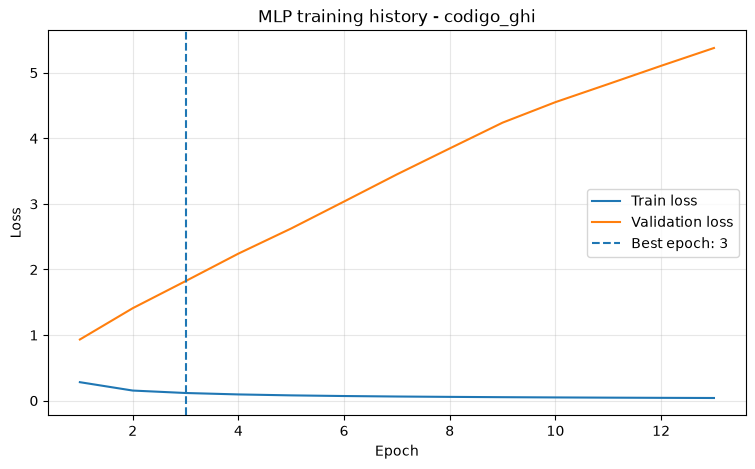

In [133]:
history_df_ghi = pd.DataFrame(
    mlp_histories["codigo_ghi"].history
)

best_epoch_ghi = best_epochs[
    "codigo_ghi"
]

plt.figure(figsize=(9, 5))

plt.plot(
    history_df_ghi.index + 1,
    history_df_ghi["loss"],
    label="Train loss",
)

plt.plot(
    history_df_ghi.index + 1,
    history_df_ghi["val_loss"],
    label="Validation loss",
)

plt.axvline(
    best_epoch_ghi,
    linestyle="--",
    label=f"Best epoch: {best_epoch_ghi}",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP training history - codigo_ghi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

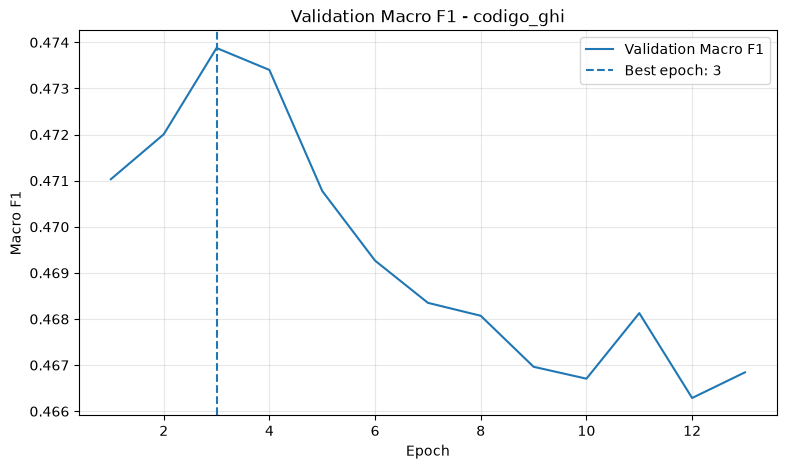

In [149]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df_ghi.index + 1,
    history_df_ghi["val_macro_f1"],
    label="Validation Macro F1",
)

plt.axvline(
    best_epoch_ghi,
    linestyle="--",
    label=f"Best epoch: {best_epoch_ghi}",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1 - codigo_ghi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

En `codigo_ghi` se observa una reducción continua de la pérdida de entrenamiento mientras la pérdida de validación aumenta desde las primeras épocas, indicando un sobreajuste temprano en términos probabilísticos. No obstante, el Macro F1 de validación mejora ligeramente durante las primeras iteraciones y alcanza su máximo en la tercera época, que es la seleccionada al tratarse de la métrica principal del proyecto.

El gráfico se utiliza como ejemplo representativo del comportamiento del entrenamiento y no se replica para los otros targets para evitar visualizaciones redundantes.


## 14.6 Resultados de validación

Los mejores valores de Macro F1 en validación son **0,474 para GHI**, **0,343 para DNI** y **0,484 para DHI**, alcanzados en las épocas 3, 29 y 4 respectivamente.

Los resultados muestran una capacidad de generalización limitada durante la validación interna, especialmente para DNI. Dado que el objetivo de este bloque es evaluar la viabilidad del enfoque MLP, no se realiza una optimización adicional de hiperparámetros y se procede a evaluar los modelos seleccionados sobre el test externo.

In [134]:
validation_summary = []

for target in TARGETS:

    history_df = pd.DataFrame(
        mlp_histories[target].history
    )

    validation_summary.append({
        "target": target,
        "best_epoch": (
            history_df["val_macro_f1"]
            .idxmax()
            + 1
        ),
        "best_val_macro_f1": (
            history_df["val_macro_f1"]
            .max()
        ),
    })

validation_summary = pd.DataFrame(
    validation_summary
)

validation_summary

,target,best_epoch,best_val_macro_f1
0,codigo_ghi,3,0.473878
1,codigo_dni,29,0.342560
2,codigo_dhi,4,0.484165


## 14.7 Evaluación sobre el test externo de 2023

Los modelos correspondientes a la mejor época de validación se evalúan finalmente sobre **2023**, conjunto que no ha intervenido en el entrenamiento ni en la selección de las épocas.

La evaluación mantiene exactamente las métricas definidas para el resto del proyecto: **Macro F1 como métrica principal**, acompañada de Balanced Accuracy y Weighted F1.

In [135]:
mlp_predictions = {}

for target in TARGETS:

    y_prob = mlp_models[target].predict(
        X_test,
        verbose=0,
    )

    n_classes = len(
        np.unique(y_fit[target])
    )

    if n_classes == 2:

        y_pred = (
            y_prob.ravel() >= 0.5
        ).astype(int)

    else:

        y_pred = np.argmax(
            y_prob,
            axis=1,
        )

    mlp_predictions[target] = y_pred

In [136]:
mlp_test_results = evaluate_model_predictions(
    test_df=test_df,
    predictions=mlp_predictions,
    targets=TARGETS,
    model_name="MLP",
    features=used_features,
)

mlp_test_results

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,MLP,codigo_ghi,14,0.743533,0.782470,0.883894
1,MLP,codigo_dni,14,0.462769,0.675691,0.904146
2,MLP,codigo_dhi,14,0.451350,0.515467,0.842825


Los resultados sobre el test externo muestran diferencias importantes entre los tres targets. `codigo_ghi` obtiene el mejor comportamiento con un **Macro F1 de 0,744**, mientras que `codigo_dni` y `codigo_dhi` alcanzan valores considerablemente inferiores de **0,463 y 0,451**, respectivamente.

El elevado Weighted F1, especialmente en DNI y DHI, contrasta con sus valores de Macro F1 y confirma la influencia del fuerte desbalance de clases. Por ello, la métrica ponderada no debe utilizarse de forma aislada para valorar estos modelos.

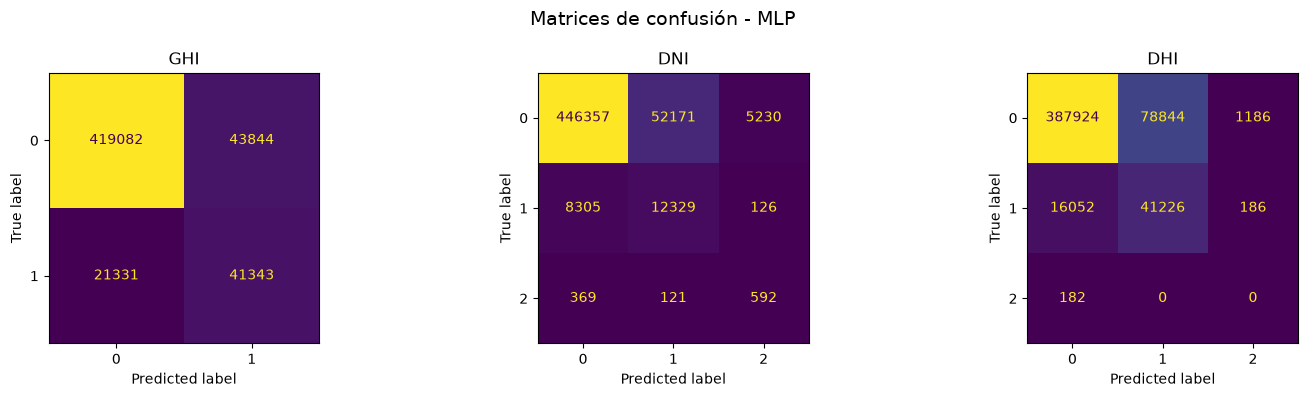

In [137]:
plot_confusion_matrices(
    test_df=test_df,
    predictions=mlp_predictions,
    targets=TARGETS,
    model_name="MLP",
)

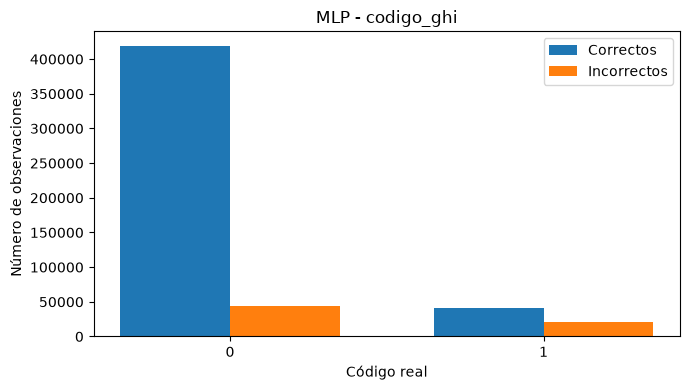

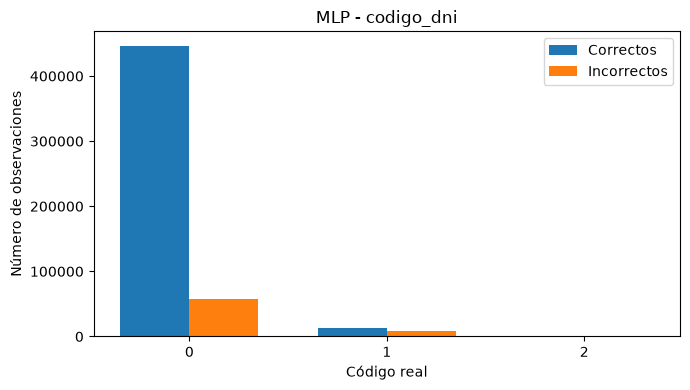

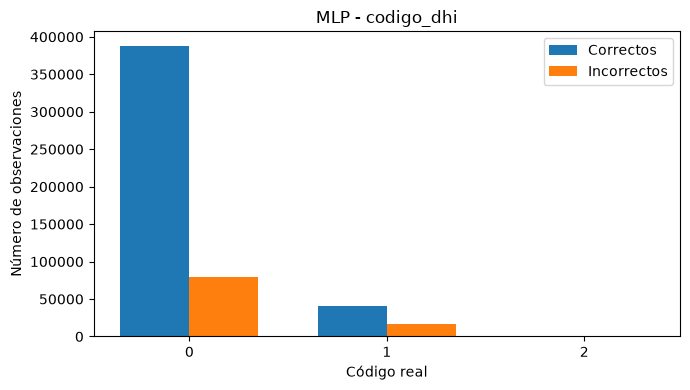

In [138]:
plot_correct_predictions_by_class(
    test_df=test_df,
    predictions=mlp_predictions,
    targets=TARGETS,
    model_name="MLP",
)

Las matrices de confusión y el análisis por clase confirman que el rendimiento agregado está condicionado por la elevada presencia de las clases mayoritarias. El modelo identifica con mayor facilidad las observaciones pertenecientes a los códigos predominantes, mientras que presenta mayores dificultades sobre las clases minoritarias.

Este comportamiento es especialmente relevante en DNI, donde la clase más infrecuente representa una proporción muy reducida del conjunto de datos.

## 14.8 Conclusiones

La incorporación de Spark ha permitido realizar la carga, transformación y particionado del dataset mediante un flujo de procesamiento distribuido antes de su utilización en TensorFlow.

La arquitectura MLP obtiene su mejor resultado para GHI, mientras que su rendimiento sobre DNI y DHI resulta limitado, especialmente al considerar Macro F1 y el comportamiento por clase. Además, se detecta una tendencia al sobreajuste y una sensibilidad relevante al desbalance de los targets.

En consecuencia, los resultados **no justifican aumentar la complejidad del enfoque mediante un proceso específico de optimización de la MLP**. El modelo se conserva como experimento de Deep Learning dentro del proyecto y sus resultados se integrarán en el siguiente notebook junto con los modelos clásicos para realizar la comparación y selección final. 

## 14.9 Persistencia de resultados

Una vez evaluados los modelos MLP sobre el conjunto de test externo, sus resultados se almacenan utilizando la misma arquitectura de persistencia empleada para los modelos anteriores.

Se utilizan dos sistemas complementarios:

- **PostgreSQL**, para registrar de forma estructurada la configuración de cada modelo y sus métricas globales de evaluación.
- **MongoDB**, para almacenar los resultados diarios de las predicciones y mantener su relación con los resúmenes diarios ya disponibles.

Esta separación permite conservar tanto una visión agregada del rendimiento de los modelos como el detalle temporal necesario para posteriores análisis.

In [139]:
from src.database.postgresql_persistence import (
    save_model_results_postgresql,
)

from src.mongodb.mongodb_persistence import (
    save_model_results_mongodb,
)

### 14.9.1 Configuración del experimento

Se define la información necesaria para identificar el experimento en las bases de datos, incluyendo la versión del dataset, los años utilizados para entrenamiento y test, las variables empleadas y los principales hiperparámetros de la arquitectura MLP.

También se almacenan las mejores épocas identificadas durante la validación interna para cada target.

In [ ]:
MODEL_NAME = "MLP"

mlp_hyperparameters = {
    "hidden_layers": [64, 32],
    "activation": "relu",
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "batch_size": 256,
    "max_epochs": 100,
    "early_stopping_monitor": "val_macro_f1",
    "early_stopping_patience": 10,
    "validation_ratio": VALIDATION_RATIO,
    "best_epochs_by_target": {
        target: int(epoch)
        for target, epoch in best_epochs.items()
    },
}

### 14.9.2 Registro en PostgreSQL

Los resultados globales de cada target se registran en PostgreSQL. Para cada modelo se almacena su configuración en la tabla de modelos y las métricas obtenidas sobre el test externo en la tabla de resultados.

La operación devuelve un identificador único `model_id` para cada target, que permitirá relacionar posteriormente estos registros con la información almacenada en MongoDB.

In [ ]:
mlp_model_ids = save_model_results_postgresql(
    results_df=mlp_test_results,
    model_name=MODEL_NAME,
    dataset_version="processed_dataset_solar_v3",
    features=used_features,
    hyperparameters=mlp_hyperparameters,
    train_year=TRAIN_YEAR,
    test_year=TEST_YEAR,
)

mlp_model_ids

MLP guardado correctamente para 3 targets.


[22, 23, 24]

In [144]:
mlp_model_ids_by_target = dict(
    zip(
        mlp_test_results["target"],
        mlp_model_ids,
    )
)

mlp_model_ids_by_target

{'codigo_ghi': 22, 'codigo_dni': 23, 'codigo_dhi': 24}

Los tres modelos MLP han quedado registrados de forma independiente, manteniendo un identificador específico para `codigo_ghi`, `codigo_dni` y `codigo_dhi`.

Estos identificadores se utilizan como referencia común entre PostgreSQL y MongoDB, permitiendo mantener la trazabilidad de cada experimento entre ambos sistemas de almacenamiento.

### 14.9.3 Registro en MongoDB

A partir de las predicciones minuto a minuto del test de 2023, los resultados se agrupan por día y se incorporan a los documentos `daily_summaries` existentes en MongoDB.

Para cada fecha y target se almacena información como las métricas diarias, distribución de clases reales y predichas, matriz de confusión y el `model_id` correspondiente de PostgreSQL.

De esta forma, MongoDB conserva el detalle temporal de los resultados sin duplicar los documentos diarios ya existentes.

In [148]:
mongodb_result = save_model_results_mongodb(
    test_df=test_df,
    predictions=mlp_predictions,
    model_name=MODEL_NAME,
    model_ids_by_target=mlp_model_ids_by_target,
    dataset_version="v3",
    features=used_features,
    targets=TARGETS,
    train_year=TRAIN_YEAR,
    test_year=TEST_YEAR,
)

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found i

Días procesados correctamente: 365
Días con error: 0


La persistencia permite integrar los resultados del MLP dentro de la misma estructura utilizada por el resto de modelos del proyecto. PostgreSQL conserva la información global del experimento, mientras que MongoDB permite consultar su comportamiento con granularidad diaria.

Los resultados quedan así disponibles para la comparación conjunta y selección de modelos que se realizará en el siguiente notebook.

In [147]:
spark.stop()

print("Spark session stopped.")

Spark session stopped.
